## SITCOM-2049



In [18]:
#Setting packages
import asyncio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
import time
import warnings
import seaborn as sns
import datetime as dt
from scipy import stats
import matplotlib.dates
from matplotlib.dates import DateFormatter
#from astropy.table import Table, join
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import IsolationForest
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from lsst.utils.packages import getEnvironmentPackages
import pymannkendall as mk
#%matplotlib widget

from astropy.time import Time, TimeDelta
from lsst_efd_client.efd_helper import merge_packed_time_series
from lsst.meas.algorithms.installGaussianPsf import FwhmPerSigma
from lsst.daf.butler import Butler 
#from tqdm.notebook import tqdm

# Ignore the many warning messages from ``merge_packed_time_series``
warnings.simplefilter(action="ignore", category=FutureWarning)

#-------Clients
from lsst_efd_client import EfdClient
client = EfdClient("usdf_efd")
from lsst.summit.utils.efdUtils import (
    getEfdData,
    getDayObsEndTime,
    getDayObsForTime,
    getDayObsStartTime,
    makeEfdClient,
)

#from lsst.summit.utils.efdUtils import makeEfdClient
#client = makeEfdClient()

#from lsst.summit.utils import ConsDbClient
#os.environ["no_proxy"] += ",.consdb"
#url="http://consdb-pq.consdb:8080/consdb"
#consdb=ConsDbClient(url)
#-------Clients



In [19]:
### function 

def float_hours(h,m,s,ms):
    f = (h * 3600 +
    m * 60 +
    s +
    ms / 1e6) /3600

    return f

In [20]:
#Initialize an EFD client
efd_client = makeEfdClient()

# EFD Data pull 

In [21]:
#Observation time-- select a month
## We go a month in time -- could go larger 
start_time = Time("2025-10-01T00:00:00Z", scale="utc")
end_time = Time("2026-04-24T23:59:00Z", scale="utc")

In [22]:
## pullling a subset of columns from the EFD 
df_script = getEfdData(
             client=efd_client,
             topic="lsst.sal.ScriptQueue.logevent_script",
             #columns=["*"],         
    columns=["private_efdStamp","cmdId","salIndex","path","scriptState", "scriptSalIndex","processState","timestampProcessStart", "timestampConfigureStart", "timestampConfigureEnd", "timestampRunStart" ],
             begin=start_time,
             end=end_time,
)

In [23]:
# filter: MTQ and selecting entries for a common cmdId

df_filt=df_script[(df_script['salIndex']==1)].groupby('cmdId').tail(1) ## 

### NOTEs: 
#### 1. Script SAL ids are NOT unique because they get recycled every time the scriptQ gets restarted (no cadence of this!) 
#### 2. When a script is terminated-- it turns that the delta_t (i.e total time between configure start to end ) goes -1.7e-9. That is becaise there is NO timestanp for ConfigureEnd 

In [24]:
#df_filt['configure_start']=pd.to_datetime(df_filt['timestampConfigureStart'], unit='s')
#df_filt['configure_end']=pd.to_datetime(df_filt['timestampConfigureEnd'], unit='s')
df_filt['tdelta_config']= (df_filt['timestampConfigureEnd']-df_filt['timestampConfigureStart'])
df_filt['weekday']=df_filt.index.day_name() ## extarcting week day from the datetime object 
df_filt['tod']= float_hours(df_filt.index.hour,df_filt.index.minute,df_filt.index.second, df_filt.index.microsecond)# extracting time from the date-time index 
df_filt['month']=df_filt.index.month_name() ## extracting month from the datetime object
#df_filt['year']=df_filt.index.month_name() ## extracting month from the datetime object


df_filt['timestamp_sc']=df_filt.index

## data checks 

In [10]:
#print(min(df_filt[df_filt['tdelta_12']<0]['processState']))
#start_time.strftime('%Y-%m-%d')
#df_filt['tod'].dtype
#print(np.__version__)
#print( df['column_name'].str.split('_').str[0])

# Latency time analysis 

#### the maximum latency observed in this time period is a 1 min & min is 0 (sounds a bit impractical!); average is about 9 secs 

In [28]:
# Select the month you want to display 
df =df_filt[(df_filt['tdelta_config']>=0) & (df_filt['month']=='April')]

## Visualisation: Time Series analysis Weekday vs Hour of the day and the configure latency (monthly lookout) 

#### This plot gives a monthly look at how quickly the scripts got configured. Ideally, they should get configured as soon as loaded (i.e. 0 s) but that is impractical. We will define a relaxed 5% of a minute as the threshold for requirement of rapid script configuration time. 
#### 1. the ideal average script config time should be <= 5% of a minute i.e. <= 3s 
#### 2. typical NO begins from 22:00 UTC to 09:30 + 1 UTC. As such, 

#### --> Scripts with longest config times --- its not helpful without weekday seasonality 

In [ ]:
df.nlargest(20, 'tdelta_config') ## gives top 10 scripts with longest config times-- these are mostly  non-scheduler scripts. 

In [115]:
max(df['month'].values)

'March'

### --> what is the variance of script config times for different outlier scripts 


In [29]:
x=df['tdelta_config'].groupby(df['path'].values).agg(['mean','var','count']).reset_index().dropna()

In [214]:
x=x.sort_values(by='count')

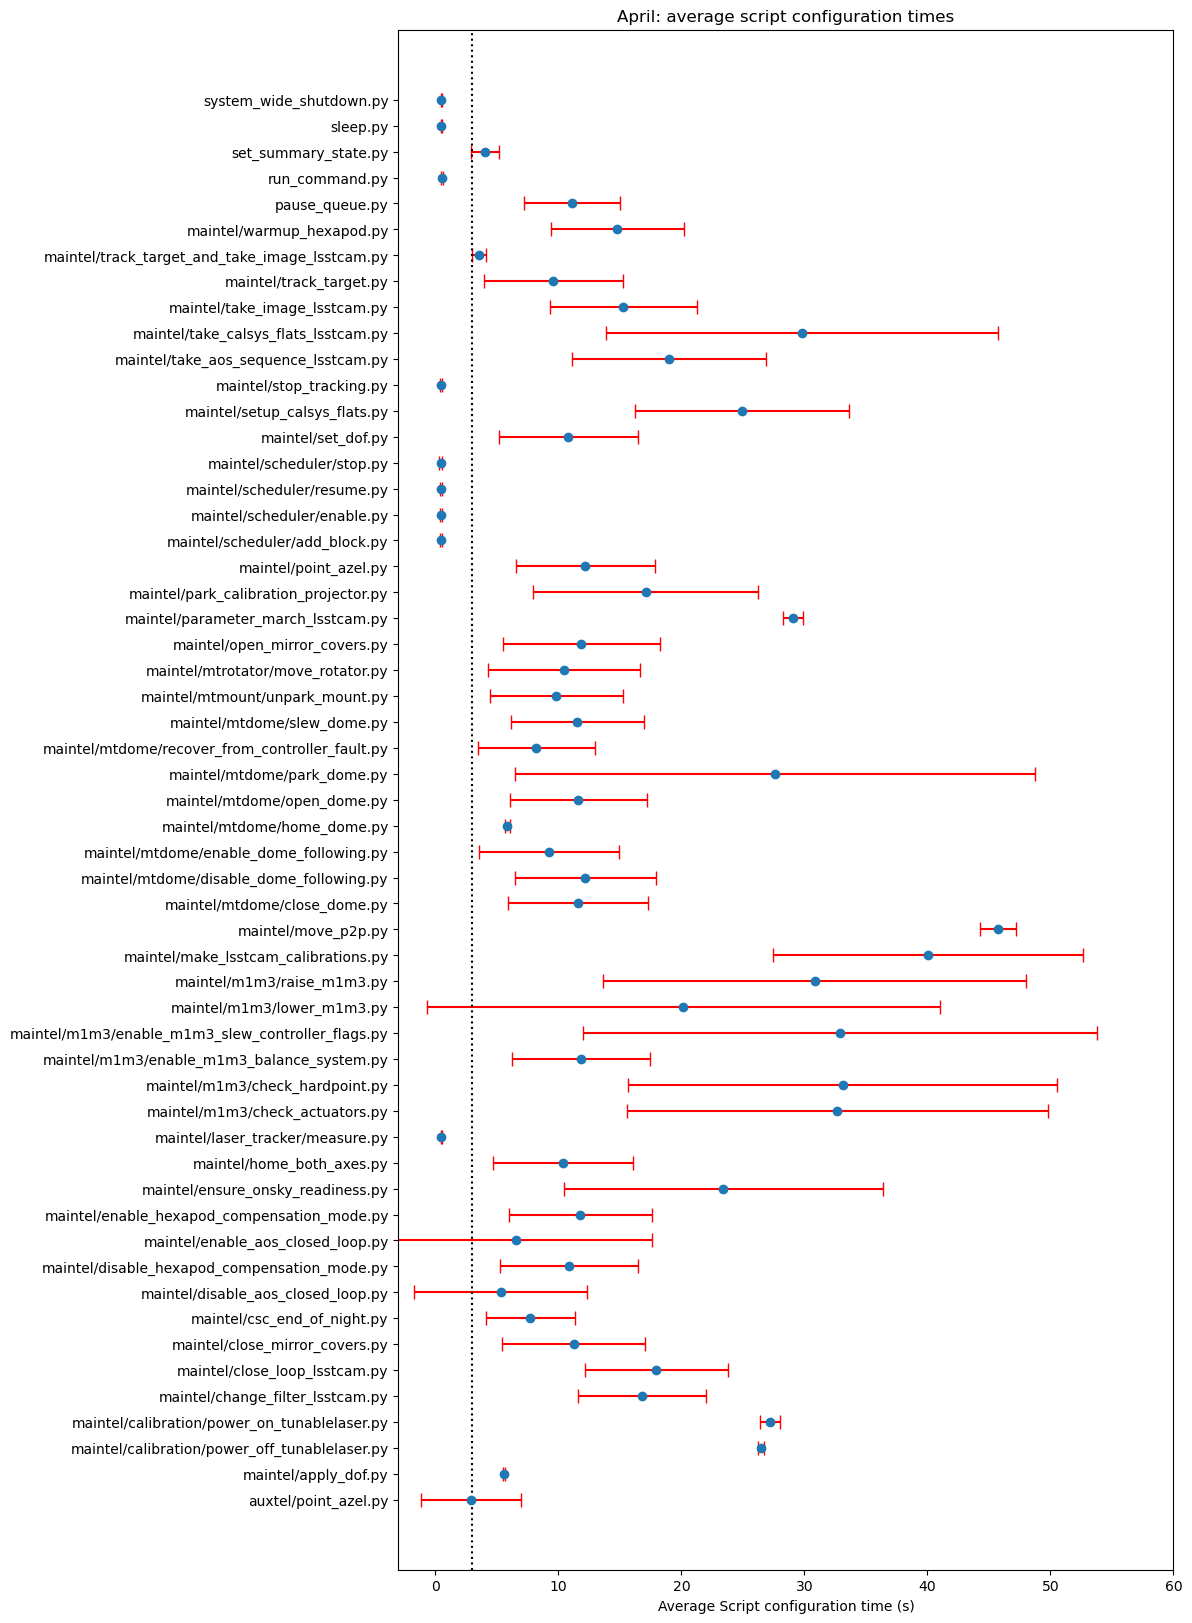

In [30]:
plt.figure(figsize=(10, 20))

plt.errorbar(x['mean'], x['index'], xerr=np.sqrt(x['var']), fmt='o', capsize=5, ecolor='red')
plt.axvline(x=3, c='k', linestyle='dotted')
plt.xlim(-3,60)
plt.title(str(max(df['month'].values))+': average script configuration times')
plt.xlabel("Average Script configuration time (s)")
plt.savefig('avg-scriptconfig-times-script'+max(df['month'])+'.png')
#plt.scatter(x['mean'], x['index'])

### --> t_config as a function of time 

#### does note show much --- too busy to discern any trends. 

In [ ]:
plt.figure(figsize=(10, 10))
#plt.scatter(x=df['tod'].values.astype(str), y=df['weekday'])
sns.scatterplot(data= df, x=df['timestamp_sc'].values.astype(str) , y=df['tdelta_config'] )
#plt.plot(df['tod'].values.astype(str)  ,df['weekday'].values.astype(str) )
#plt.xticks(np.arange(0,24,1))
plt.title(start_time.strftime('%Y-%m-%d')+' to '+end_time.strftime('%Y-%m-%d'))
plt.title(str(max(df['month'].values)))
#plt.text(1,7,"Average script configuring time:"+f"{mean:.3}"+" s")
#plt.text(7,7,"Longest script config delay:"+f"{mx:.3}"+" s")
#plt.xlabel("Hour of the day (UTC)")
#plt.savefig('scriptconfig-times-monthly'+max(df['month'])+'.png')
plt.show()

### --> t_config as a function of weekday and time of the day  

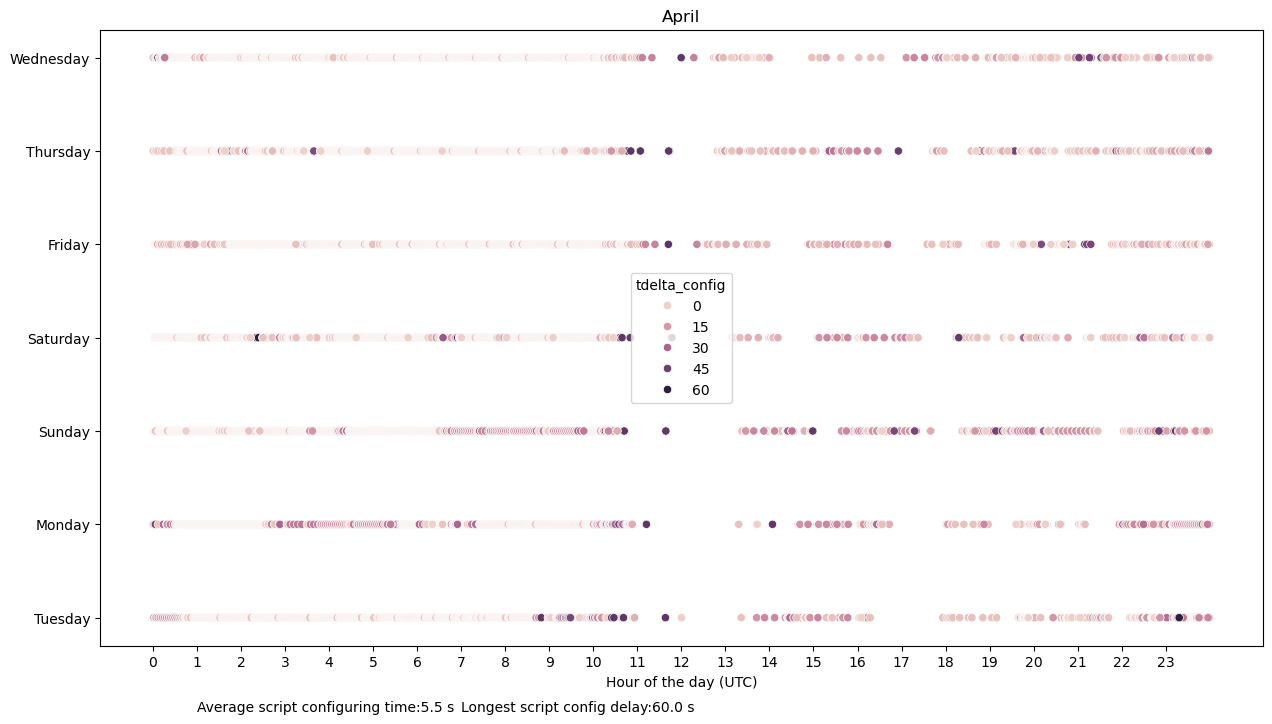

In [34]:
mean=np.mean(df['tdelta_config'])
mx=max(df['tdelta_config'])

plt.figure(figsize=(15, 8))
#plt.scatter(x=df['tod'].values.astype(str), y=df['weekday'])
sns.scatterplot(data= df, x=df['tod'] , y=df['weekday'].values.astype(str), hue=df['tdelta_config'] )
#plt.plot(df['tod'].values.astype(str)  ,df['weekday'].values.astype(str) )
plt.xticks(np.arange(0,24,1))
plt.title(start_time.strftime('%Y-%m-%d')+' to '+end_time.strftime('%Y-%m-%d'))
plt.title(str(max(df['month'].values)))
plt.text(1,7,"Average script configuring time:"+f"{mean:.3}"+" s")
plt.text(7,7,"Longest script config delay:"+f"{mx:.3}"+" s")
plt.xlabel("Hour of the day (UTC)")
plt.savefig('scriptconfig-times-monthly'+max(df['month'])+'.png')
plt.show()

#print("Average script configuring time:", str(np.mean(df['tdelta_config'])))
#print("Longest script config delay:", str(max(df['tdelta_config'])))

#### This plot shows potential weekly and daily trends. In any case the average script config time over a month is ~10 s (> 3s ) and hence source of significant overheads.  

### Mann-Kendall test for a month's data 
#### This is a non-parametric test to denote whether is increasing or decresainf trend of time. Yet to interpret the results. 

In [88]:
trend, h, p, z, Tau, s, var_s, slope, intercept = mk.original_test(df['tdelta_config'])

In [90]:
print(trend, h, p, z, Tau, s, var_s, slope, intercept)

increasing True 0.0 20.253732814205517 0.11574246057299596 10723548.0 280328185648.0 2.4027677411410808e-05 3.577880743993016


In [92]:
# for a monthly seasonality (?)
trend, h, p, z, Tau, s, var_s, slope, intercept = mk.seasonal_test(df['tdelta_config'], period=12)
print(trend, h, p, z, Tau, s, var_s, slope, intercept)

increasing True 0.0 20.25652734657887 0.1159222471878653 894294.0 1949080037.3333335 0.0002887090273018256 3.577666979803726


In [93]:
# for a weekly seasonality (?)
trend, h, p, z, Tau, s, var_s, slope, intercept = mk.seasonal_test(df['tdelta_config'], period=52)
print(trend, h, p, z, Tau, s, var_s, slope, intercept)

increasing True 0.0 20.1159738660191 0.11570982631019441 205392.0 104251111.3333333 0.0012458233606247675 3.578354005062536


## Statistical Analysis  

#### A.) The barplot or violin plot will show the overall performance with outliers. 

In [25]:
# we use the data for the entire timescale 
df2 =df_filt[(df_filt['tdelta_config']>=0)]

In [26]:
df2

,private_efdStamp,cmdId,salIndex,path,scriptState,scriptSalIndex,processState,timestampProcessStart,timestampConfigureStart,timestampConfigureEnd,timestampRunStart,tdelta_config,weekday,tod,month,timestamp_sc
2025-10-03 17:42:03.618217+00:00,1.759513e+09,47228082,1,maintel/mtrotator/move_rotator.py,10,112047,4,1.759513e+09,1.759513e+09,1.759513e+09,1.759513e+09,10.605341,Friday,17.701005,October,2025-10-03 17:42:03.618217+00:00
2025-10-03 17:43:43.779748+00:00,1.759513e+09,47228083,1,maintel/mtrotator/move_rotator.py,9,112048,4,1.759513e+09,1.759513e+09,1.759513e+09,1.759513e+09,11.110273,Friday,17.728828,October,2025-10-03 17:43:43.779748+00:00
2025-10-03 18:11:09.028072+00:00,1.759515e+09,47228084,1,maintel/mtrotator/move_rotator.py,8,112049,4,1.759515e+09,1.759515e+09,1.759515e+09,1.759515e+09,10.856050,Friday,18.185841,October,2025-10-03 18:11:09.028072+00:00
2025-10-03 22:06:24.944718+00:00,1.759529e+09,47228085,1,run_command.py,8,112050,4,1.759529e+09,1.759529e+09,1.759529e+09,1.759529e+09,0.500834,Friday,22.106929,October,2025-10-03 22:06:24.944718+00:00
2025-10-03 22:06:47.240514+00:00,1.759529e+09,47228086,1,run_command.py,8,112051,4,1.759529e+09,1.759529e+09,1.759529e+09,1.759529e+09,0.481992,Friday,22.113122,October,2025-10-03 22:06:47.240514+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-24 23:52:40.121958+00:00,1.777075e+09,63054780,1,maintel/set_dof.py,8,101071,4,1.777075e+09,1.777075e+09,1.777075e+09,1.777075e+09,5.604938,Friday,23.877812,April,2026-04-24 23:52:40.121958+00:00
2026-04-24 23:53:05.376371+00:00,1.777075e+09,63054781,1,maintel/apply_dof.py,8,101072,4,1.777075e+09,1.777075e+09,1.777075e+09,1.777075e+09,5.614571,Friday,23.884827,April,2026-04-24 23:53:05.376371+00:00
2026-04-24 23:53:27.806963+00:00,1.777075e+09,63054782,1,maintel/scheduler/add_block.py,8,101073,4,1.777075e+09,1.777075e+09,1.777075e+09,1.777075e+09,0.507207,Friday,23.891057,April,2026-04-24 23:53:27.806963+00:00
2026-04-24 23:57:25.014484+00:00,1.777075e+09,25595032,1,maintel/close_loop_lsstcam.py,8,101074,4,1.777075e+09,1.777075e+09,1.777075e+09,1.777075e+09,12.150721,Friday,23.956948,April,2026-04-24 23:57:25.014484+00:00


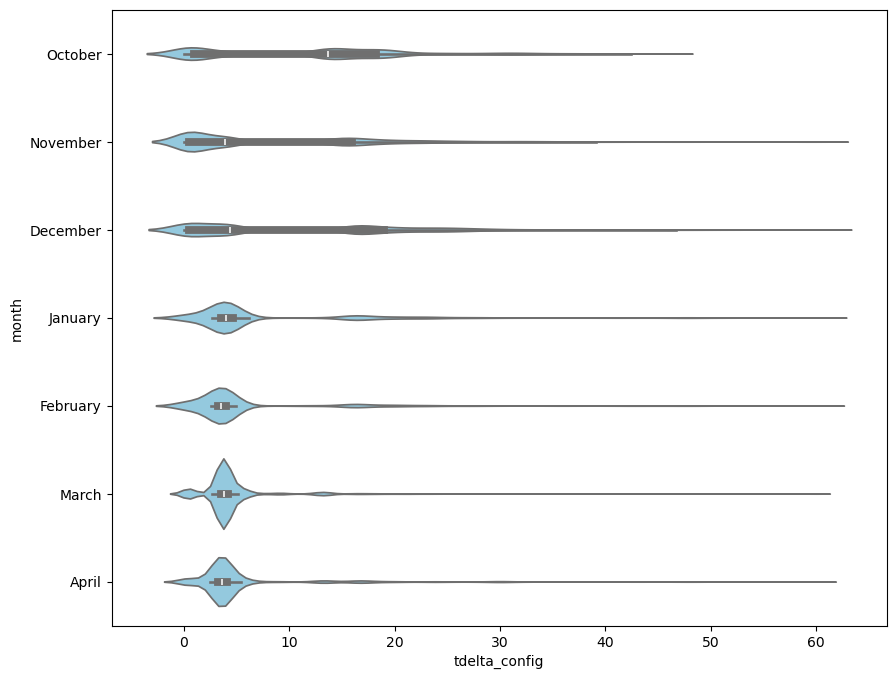

In [43]:
plt.figure(figsize=(10, 8))
sns.violinplot(data=df2, x="tdelta_config", y="month", color="skyblue")
plt.axhline(y=3, linestyle = "d")
#plt.errorbar(x['mean'], x['index'], xerr=np.sqrt(x['var']), fmt='o', capsize=5, ecolor='red')
#plt.axvline(x=3, c='k', linestyle='dotted')
#plt.xlim(-3,60)
#plt.title(str(max(df['month'].values))+': average script configuration times')

#plt.xlabel("Average Script configuration time (s)")
plt.savefig('ViolinPlot-Oct25-Apr26.png')
#plt.scatter(x['mean'], x['index'])
plt.show()

### CDF 
#### This will show the distribution of the script config latencies across the the months 

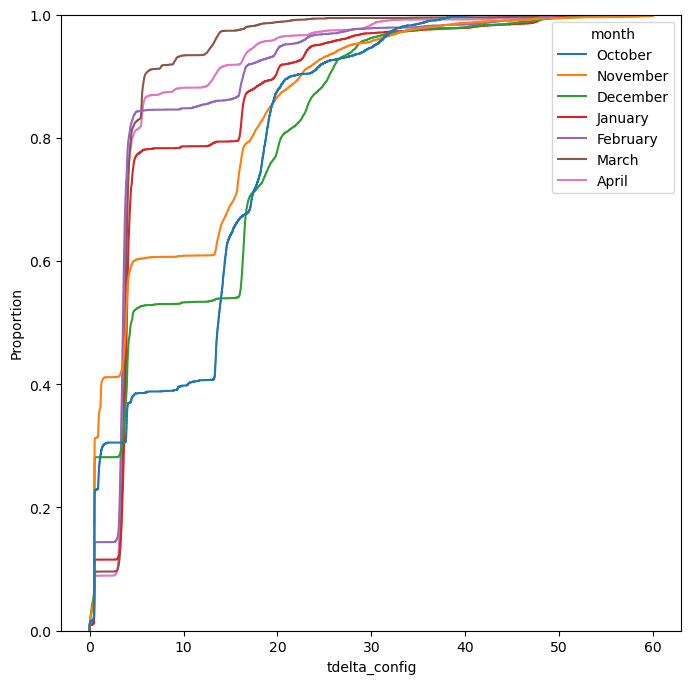

In [38]:
plt.figure(figsize=(8, 8))
sns.ecdfplot(data=df2, x="tdelta_config", hue="month", stat="proportion")

#plt.errorbar(x['mean'], x['index'], xerr=np.sqrt(x['var']), fmt='o', capsize=5, ecolor='red')
#plt.axvline(x=3, c='k', linestyle='dotted')
#plt.xlim(-3,60)
#plt.title(str(max(df['month'].values))+': average script configuration times')

#plt.xlabel("Average Script configuration time (s)")
plt.savefig('CDF-Oct25-Apr26.png')
#plt.scatter(x['mean'], x['index'])
plt.show()

### Auto correlation function
#### as evident from the lag plot this is not the right way to go --- for starters its not an equally space data. Plus I do not even know whether this the right approach-- what if the script config time is also script dependent? 

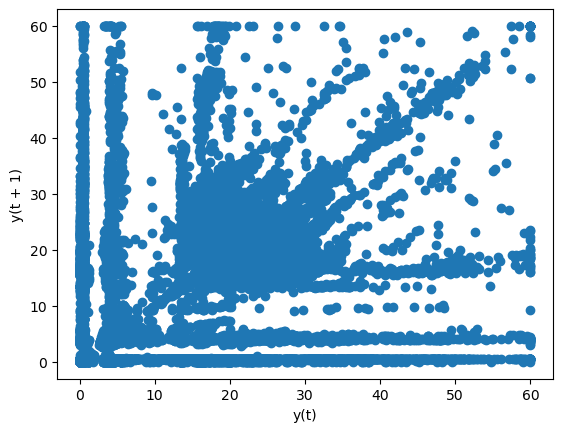

In [26]:

plt.figure()
#col_order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
#test=df.reset_index(inplace=True)
pd.plotting.lag_plot(df2['tdelta_config'],lag=1)
plt.show()

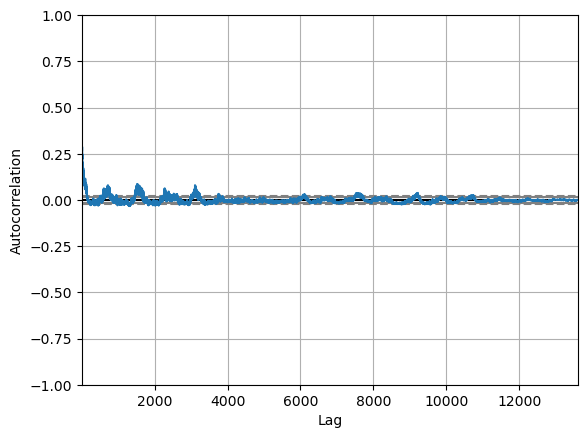

In [89]:
plt.figure()
#col_order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
#test=df.reset_index(inplace=True)
pd.plotting.autocorrelation_plot(df['tdelta_config'])
plt.show()

### Finding seasonality 

## What fraction of on-sky time do we lose due to this latency? 

### Total on-sky time is basically the dark time available for science (and NOT related to MTDome opening/clsoing OR start of the FBS). We use -12 twilight to -12 dawn. 

## Not needed--- as it turns out script config time latency is most affected by non-scheduler executions!  

In [38]:
#### private_efdStamp: UTC timestamp computed from private_sndStamp(second)-- we use this as the common stamp between between command logevents and other subsystem telemetry 
#### private_kafkaStamp TAI time at which the Kafka message was created (second)

In [105]:
## pullling a subset of columns from the EFD 
df_sunel = getEfdData(
             client=efd_client,
             topic="lsst.sal.MTPtg.skyEnvironment",
             #columns=["*"],         
    columns=["timestamp","sunriseTime","sunsetTime","private_efdStamp","sunAltitude"],
             begin=start_time,
             end=end_time,
)

In [101]:
## pullling a subset of columns from the EFD 
#df_sunel_test = getEfdData(
#             client=efd_client,
#             topic="lsst.sal.MTPtg.skyEnvironment",
#             #columns=["*"],         
#    columns=["private_efdStamp","sunAltitude"],
#             begin=Time("2026-03-01T00:00:00Z", scale="utc"),
#             end=Time("2026-03-05T00:00:00Z", scale="utc"),
#)

In [114]:
df_sunel['Obsdate']= df_sunel.index.day
#print(df_sunel_[(df_sunel_test["sunAltitude"] <-11.95) & (df_sunel_test["sunAltitude"] > -12.05)])

In [31]:
df_sunel['timestamp_sc']=df_sunel.index
df_sunel['timestamp_24']=df_sunel.index

In [32]:
#### Calculate the total duration of the dark time from -12 to -12 dark time 

In [52]:
df_sunel=df_sunel[df_sunel["sunAltitude"]<=-12]
#l=df_sunel.groupby(pd.Grouper(key='timestamp_24',freq='24H', origin='start_day', offset='-4H')).
#l

In [ ]:
l=df_sunelf.groupby('day')['lat_disable_enable_s'].mean().reset_index()

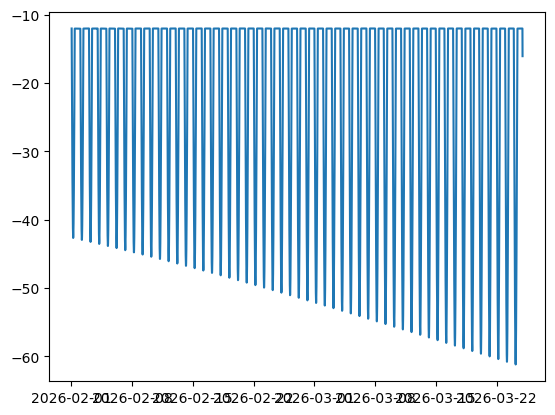

In [53]:
plt.plot(df_sunel["sunAltitude"]

In [13]:
merged_df = pd.merge_asof(df, df_sunel, on="timestamp_sc")